# Import libraries

In [4]:
# %pip install tensorly numpy matplotlib torch tqdm h5py scikit-image scikit-learn pandas
# %pip install --upgrade scikit-image reportlab seaborn

In [5]:
# Standard library imports
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import numpy as np
import tensorly as tl
from pathlib import Path
from tqdm import tqdm
from typing import Optional, Tuple, Dict, List, Literal


# Local TBMD module imports
from TBMD.modules.TensorHOSVD import TuckerDecomposer
from TBMD.modules.TensorTimeInsensitiveModes import (
    BatchModalProcessor, 
    ModalTensorStacker, 
    ModalProcessorConfig, 
    ProcessingStrategy,
)
from TBMD.modules.TensorBasedTubeFiberPivotQRFactorization import (
    TensorTubeQRDecomposition,
    TensorQRConfig
)
# TBMD utilities imports
from TBMD.utils.utils import (
    build_wells_matrix
)
from TBMD.utils.plots import (
    visualize_tensor,
)
from TBMD.utils.process_data import (
    process_data, 
    calculate_global_minmax_params, 
    calculate_global_zscore_params, 
)
from TBMD.utils.split_data import split_data_in_memory_ordered, split_data_in_memory

from TBMD.utils.DataLoader import DataLoader
from TBMD.config import SEED, SET_BACKEND

In [6]:
tl.check_random_state(SEED)
np.random.seed(SEED)

tl.set_backend(SET_BACKEND)

torch.set_printoptions(precision=4, sci_mode=False)

# Download data

In [7]:
loader = DataLoader()

### Load Brugge data

(x,y, variants_geo, count_var, timestemp)

In [8]:
# Проверка правильности реализации

# Списки путей к данным и скважинам
data_paths = [
    "/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/data/Brugge data/data_exp_4_.h5"
]
wells_paths = [
    "/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/data/Brugge data/all_wells_exp_4.json"
]

tensors_list = []
wells_list = []

# Проверяем, что количество путей совпадает
assert len(data_paths) == len(wells_paths), "Количество файлов данных и файлов скважин должно совпадать"

for d_path, w_path in zip(data_paths, wells_paths):
    # Загрузка тензоров
    tensor = loader.load_h5_tensors(d_path)
    tensors_list.append(tensor)

    # Загрузка скважин
    wells = loader.load_wells_from_json(w_path)
    # Проверка структуры wells: должен быть словарь с case_id -> список координат
    assert isinstance(wells, dict), f"wells должен быть dict, а не {type(wells)}"
    for case_id in wells:
        # Проверяем, что каждая точка - пара координат
        wells[case_id] = [[x, y] for x, y in wells[case_id]]
        for pair in wells[case_id]:
            assert isinstance(pair, list) and len(pair) == 2, f"Координаты должны быть списком из двух элементов, а не {pair}"
    wells_list.append(wells)


In [9]:
# train_data, test_data = split_data_in_memory_ordered(tensors['all'], train_ratio=0.8)

# subject_name = list(tensors['all'].keys())[0]

# print(list(tensors['all'].keys()))
# print(tensors['all'][subject_name].shape)

In [10]:
train_data_list = []
test_data_list = []

for tensor in tensors_list:
    train_data, test_data = split_data_in_memory_ordered(tensor['pressure'], train_ratio=0.8)
    train_data_list.append(train_data)
    test_data_list.append(test_data)
    for subject_name in tensor['pressure'].keys():
        print(subject_name)
        print(tensor['pressure'][subject_name].shape)

Experiments processed: 100%|██████████| 10/10 [00:00<00:00, 97769.32it/s]

case1
(139, 48, 133)
case2
(139, 48, 133)
case3
(139, 48, 133)
case4
(139, 48, 133)
case5
(139, 48, 133)
case6
(139, 48, 133)
case7
(139, 48, 133)
case8
(139, 48, 133)
case9
(139, 48, 133)
case10
(139, 48, 133)


In [11]:
# train_data_list = []
# test_data_list = []

# for tensor in tensors_list:
#     train_data, test_data = split_data_in_memory_ordered(tensor['soil'], train_ratio=0.8)
#     train_data_list.append(train_data)
#     test_data_list.append(test_data)
#     for subject_name in tensor['soil'].keys():
#         print(subject_name)
#         print(tensor['soil'][subject_name].shape)

### Load static csv data

In [12]:
# # Load static tensor
# static_data = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/HW static data"), "static", (286, 105, 100), tensor_type="pt")

# noisy_datasets = generate_noisy_datasets(
#     data=static_data,
#     noise_level=0.1,
#     num_noisy_datasets=5,
#     experiment_id="001"
# )

# train_data, test_data = split_data_in_memory_ordered(noisy_datasets, train_ratio=0.8)

# subject_name = list(noisy_datasets.keys())[0]

# print(list(noisy_datasets.keys()))
# print(noisy_datasets[subject_name].shape)

### Load dynamic csv data

In [13]:
# # Load dynamic tensor
# dynamic_data = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/HW dynamic data"), "dynamic", (286, 105, 25, 253), tensor_type="pt")

# train_data, test_data = split_data_in_memory_ordered(dynamic_data, train_ratio=0.8)

# subject_name = list(dynamic_data.keys())[0]

# print(list(dynamic_data.keys()))
# print(dynamic_data[subject_name].shape)

### Load images

In [14]:
# # Load images tensor
# images_data, subject_list = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/data/HW data/dynamic_png_new"), "images", tensor_type="pt")

# train_data, test_data = split_data_in_memory_ordered(images_data, train_ratio=0.8)

# subject_name = subject_list[0]

# print(subject_list)
# print(images_data[subject_name].shape)

In [15]:
# num_experiments = 2
# experiments_data = split_data_in_memory(images_data, num_experiments=num_experiments, train_ratio=0.8)

# if 1 not in experiments_data:
#     raise KeyError("Experiment ID 1 does not exist in 'experiments_data'.")

# train_data = experiments_data[1].get("train", {})
# test_data = experiments_data[1].get("test", {})

# Process data

In [16]:
# Decide what counts as background (CT example)
BG = None        # Hounsfield Units for air

# Для всех train_data_list (по subject) сохранить результаты в список
minmax_params_list = []
zscore_params_list = []

for train_data in train_data_list:
    subj_min, subj_max = calculate_global_minmax_params(train_data, background_value=BG)
    subj_mean, subj_std = calculate_global_zscore_params(train_data, background_value=BG)
    minmax_params_list.append({'min': subj_min, 'max': subj_max})
    zscore_params_list.append({'mean': subj_mean, 'std': subj_std})

print("Minmax params list:", minmax_params_list)
print("Zscore params list:", zscore_params_list)

Minmax params list: [{'min': 0.0, 'max': 171.8720422674243}]
Zscore params list: [{'mean': 118.54628028736462, 'std': 70.1100889541879}]


In [17]:
resize_shape = None
convert_to_grayscale = False
normalization_method = "minmax"  # "zscore" or "minmax"

print("Processing train data:")
train_tensors_list = []
for i, train_data in enumerate(train_data_list):
    tensors = process_data(
        train_data,
        resize_shape=resize_shape,
        convert_to_grayscale=convert_to_grayscale,
        normalization_method=normalization_method,
        global_params=minmax_params_list[i],  # индивидуальные параметры для каждого subject
        background_value=BG
    )
    train_tensors_list.append(tensors)

print("\nProcessing test data:")
test_tensors_list = []
for i, test_data in enumerate(test_data_list):
    tensors = process_data(
        test_data,
        resize_shape=resize_shape,
        convert_to_grayscale=convert_to_grayscale,
        normalization_method=normalization_method,
        global_params=minmax_params_list[i],  # используем параметры train для соответствующего subject
        background_value=BG
    )
    test_tensors_list.append(tensors)

num_images_train = []
for tensors in train_tensors_list:
    num_images = {subject: tensor.shape[-1] for subject, tensor in tensors.items()}
    num_images_train.append(num_images)

num_images_test = []
for tensors in test_tensors_list:
    num_images = {subject: tensor.shape[-1] for subject, tensor in tensors.items()}
    num_images_test.append(num_images)

if num_images_train:
    min_train_images = min(
        min(subject_dict.values()) for subject_dict in num_images_train if subject_dict
)
    print(f"\nMinimum number of images in train: {min_train_images}")
else:
    print("\nNo data available for analysis in train.")

if num_images_test:
    min_test_images = min(
        min(subject_dict.values()) for subject_dict in num_images_test if subject_dict
)
    print(f"Minimum number of images in test: {min_test_images}")
else:
    print("No data available for analysis in test.")

Processing train data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      0.0000 / 171.8720
▸ Background value:      None



Processing subjects: 100%|██████████| 10/10 [00:00<00:00, 314.73it/s]


case1: (139, 48, 106)
case2: (139, 48, 106)
case3: (139, 48, 106)
case4: (139, 48, 106)
case5: (139, 48, 106)
case6: (139, 48, 106)
case7: (139, 48, 106)
case8: (139, 48, 106)
case9: (139, 48, 106)
case10: (139, 48, 106)

Processing test data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      0.0000 / 171.8720
▸ Background value:      None



Processing subjects: 100%|██████████| 10/10 [00:00<00:00, 1207.27it/s]

case1: (139, 48, 27)
case2: (139, 48, 27)
case3: (139, 48, 27)
case4: (139, 48, 27)
case5: (139, 48, 27)
case6: (139, 48, 27)
case7: (139, 48, 27)
case8: (139, 48, 27)
case9: (139, 48, 27)
case10: (139, 48, 27)

Minimum number of images in train: 106
Minimum number of images in test: 27


# Visualization

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from contextlib import contextmanager
from typing import Optional, Union, Dict, List, Tuple, Any
import warnings


def visualize_tensor(
    tensor,
    subject_name=None,
    save_path=None,
    cmap="gray",
    cols=5,
    show_colorbar=False,
    zmin=None,
    zmax=None,
    wells=None,
    frame_step=1,
    spacing=0.05  # Расстояние между изображениями в единицах от 0 до 1
):
    """
    Visualizes a tensor of images using GridSpec for precise layout control.
    
    Parameters:
      - tensor (numpy.ndarray): The data to visualize. Expected shapes:
          * (H, W, T) for grayscale images.
          * (H, W, C, T) for color images.
      - subject_name (str): Title label for the subject.
      - save_path (str): If provided, the path where the plot will be saved.
      - cmap (str): Matplotlib colormap used for imshow when displaying grayscale images.
      - cols (int): Number of columns in the grid layout.
      - show_colorbar (bool): Whether to display colorbars for each subplot.
      - zmin (float, optional): Minimum value for the color scale.
      - zmax (float, optional): Maximum value for the color scale.
      - wells (dict or list): Координаты скважин.
      - frame_step (int): Шаг для отображения кадров.
      - spacing (float): Относительное расстояние между изображениями (0.01-0.2)
    """
    # Ensure tensor has either 3 or 4 dimensions
    if tensor.ndim not in (3, 4):
        raise ValueError(f"Expected tensor with 3 or 4 dimensions, got shape {tensor.shape}.")

    # Determine the number of frames (T) and image shape
    if tensor.ndim == 3:
        H, W, T = tensor.shape
    else:  # tensor.ndim == 4
        H, W, C, T = tensor.shape

    # Выбираем кадры с заданным шагом
    frame_indices = list(range(0, T, frame_step))
    selected_frames_count = len(frame_indices)

    # Determine the number of rows needed for the grid layout
    rows = (selected_frames_count + cols - 1) // cols

    # Создаем фигуру
    fig_width = max(12, cols * 2.5)  # Минимальная ширина
    fig_height = max(8, rows * 2.5)  # Минимальная высота
    
    if subject_name:
        fig_height += 0.8  # Добавляем место для заголовка
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Создаем GridSpec с точным контролем расстояний
    if subject_name:
        gs = gridspec.GridSpec(
            rows, cols, 
            figure=fig,
            left=0.02, right=0.98, 
            bottom=0.02, top=0.92,
            wspace=spacing,  # Горизонтальное расстояние
            hspace=spacing   # Вертикальное расстояние
        )
        # Добавляем заголовок
        fig.suptitle(f"Subject: {subject_name}", fontsize=20, y=0.96)
    else:
        gs = gridspec.GridSpec(
            rows, cols, 
            figure=fig,
            left=0.02, right=0.98, 
            bottom=0.02, top=0.98,
            wspace=spacing,
            hspace=spacing
        )

    # Создаем субплоты
    for display_idx in range(selected_frames_count):
        row_idx = display_idx // cols
        col_idx = display_idx % cols
        
        # Получаем реальный индекс кадра
        frame_idx = frame_indices[display_idx]
        
        # Создаем subplot в нужной позиции
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        # Extract the frame depending on tensor dimensions
        if tensor.ndim == 3:
            frame = tensor[:, :, frame_idx]
            
            # Determine vmin and vmax for this frame
            current_zmin = zmin
            if current_zmin is None:
                non_zero_frame = frame[frame != 0]
                if non_zero_frame.size > 0:
                    current_zmin = non_zero_frame.min()
                else:
                    current_zmin = 0

            current_zmax = zmax
            if current_zmax is None:
                current_zmax = frame.max()
                if current_zmax <= current_zmin and current_zmax == 0:
                    current_zmax = 1

            im = ax.imshow(frame, cmap=cmap, aspect="equal", vmin=current_zmin, vmax=current_zmax)
        else:  # 4D tensor: display color image
            frame = tensor[:, :, :, frame_idx]
            im = ax.imshow(frame, aspect="equal")
            
        ax.set_title(f"Frame {frame_idx + 1}", fontsize=12, pad=3)
        
        # Отображение скважин
        if wells is not None:
            wells_to_plot = None
            if subject_name is not None:
                if isinstance(wells, dict):
                    wells_to_plot = wells.get(subject_name)
                    if isinstance(wells_to_plot, dict):
                        wells_to_plot = wells_to_plot.get(frame_idx)
                    elif wells_to_plot is None:
                        wells_to_plot = wells.get(f"{subject_name}_{frame_idx}")
            else:
                if isinstance(wells, list) or (isinstance(wells, np.ndarray) and wells.ndim >= 2):
                    wells_to_plot = wells
            
            if wells_to_plot is not None and len(wells_to_plot) > 0:
                wells_array = np.array(wells_to_plot)
                ax.scatter(wells_array[:, 0], wells_array[:, 1], c='red', marker='o', s=40, label='Wells')
                ax.legend(loc='upper right', fontsize=8)
        
        # Добавляем colorbar если нужно
        if show_colorbar and tensor.ndim == 3:
            # Создаем отдельный subplot для colorbar
            divider_pos = [ax.get_position().x1 + 0.01, ax.get_position().y0, 0.02, ax.get_position().height]
            cax = fig.add_axes(divider_pos)
            fig.colorbar(im, cax=cax)
            
        ax.axis("off")

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", pad_inches=0.05)
        print(f"Saved visualization to: {save_path}")
        plt.close(fig)
    else:
        plt.show()


def visualize_tensor_ultra_compact(
    tensor,
    subject_name=None,
    save_path=None,
    cmap="gray",
    cols=5,
    show_colorbar=False,
    zmin=None,
    zmax=None,
    wells=None,
    frame_step=1
):
    """
    Ультра-компактная визуализация без промежутков между изображениями.
    Использует один большой subplot с мозаикой изображений.
    """
    if tensor.ndim not in (3, 4):
        raise ValueError(f"Expected tensor with 3 or 4 dimensions, got shape {tensor.shape}.")

    if tensor.ndim == 3:
        H, W, T = tensor.shape
    else:
        H, W, C, T = tensor.shape

    frame_indices = list(range(0, T, frame_step))
    selected_frames_count = len(frame_indices)
    rows = (selected_frames_count + cols - 1) // cols

    # Создаем мозаику изображений
    if tensor.ndim == 3:
        # Создаем большое изображение-мозаику
        mosaic_height = H * rows
        mosaic_width = W * cols
        mosaic = np.zeros((mosaic_height, mosaic_width))
        
        for display_idx in range(selected_frames_count):
            row_idx = display_idx // cols
            col_idx = display_idx % cols
            frame_idx = frame_indices[display_idx]
            
            frame = tensor[:, :, frame_idx]
            
            # Позиция в мозаике
            y_start = row_idx * H
            y_end = (row_idx + 1) * H
            x_start = col_idx * W
            x_end = (col_idx + 1) * W
            
            mosaic[y_start:y_end, x_start:x_end] = frame
    else:
        # Для цветных изображений
        mosaic_height = H * rows
        mosaic_width = W * cols
        mosaic = np.zeros((mosaic_height, mosaic_width, tensor.shape[2]))
        
        for display_idx in range(selected_frames_count):
            row_idx = display_idx // cols
            col_idx = display_idx % cols
            frame_idx = frame_indices[display_idx]
            
            frame = tensor[:, :, :, frame_idx]
            
            y_start = row_idx * H
            y_end = (row_idx + 1) * H
            x_start = col_idx * W
            x_end = (col_idx + 1) * W
            
            mosaic[y_start:y_end, x_start:x_end, :] = frame

    # Отображаем мозаику
    fig_width = max(10, cols * 2)
    fig_height = max(8, rows * 2)
    
    if subject_name:
        fig_height += 1
        
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
    
    if tensor.ndim == 3:
        current_zmin = zmin if zmin is not None else mosaic[mosaic != 0].min() if mosaic[mosaic != 0].size > 0 else 0
        current_zmax = zmax if zmax is not None else mosaic.max()
        if current_zmax <= current_zmin:
            current_zmax = current_zmin + 1
        im = ax.imshow(mosaic, cmap=cmap, aspect="equal", vmin=current_zmin, vmax=current_zmax)
    else:
        im = ax.imshow(mosaic.astype(np.uint8), aspect="equal")
    
    # Добавляем линии-разделители и подписи
    for row in range(1, rows):
        ax.axhline(y=row * H - 0.5, color='white', linewidth=1, alpha=0.3)
    for col in range(1, cols):
        ax.axvline(x=col * W - 0.5, color='white', linewidth=1, alpha=0.3)
    
    # Добавляем подписи кадров
    for display_idx in range(selected_frames_count):
        row_idx = display_idx // cols
        col_idx = display_idx % cols
        frame_idx = frame_indices[display_idx]
        
        x_center = col_idx * W + W // 2
        y_center = row_idx * H + 10  # Ближе к верху
        
        ax.text(x_center, y_center, f"Frame {frame_idx + 1}", 
               ha='center', va='center', color='white', fontsize=10, 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
    
    # Отображение скважин
    if wells is not None:
        for display_idx in range(selected_frames_count):
            row_idx = display_idx // cols
            col_idx = display_idx % cols
            frame_idx = frame_indices[display_idx]
            
            wells_to_plot = None
            if subject_name is not None:
                if isinstance(wells, dict):
                    wells_to_plot = wells.get(subject_name)
                    if isinstance(wells_to_plot, dict):
                        wells_to_plot = wells_to_plot.get(frame_idx)
            else:
                if isinstance(wells, list) or (isinstance(wells, np.ndarray) and wells.ndim >= 2):
                    wells_to_plot = wells
            
            if wells_to_plot is not None and len(wells_to_plot) > 0:
                wells_array = np.array(wells_to_plot)
                # Пересчитываем координаты для мозаики
                mosaic_wells_x = wells_array[:, 0] + col_idx * W
                mosaic_wells_y = wells_array[:, 1] + row_idx * H
                ax.scatter(mosaic_wells_x, mosaic_wells_y, c='red', marker='o', s=30)
    
    if show_colorbar and tensor.ndim == 3:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    if subject_name:
        ax.set_title(f"Subject: {subject_name}", fontsize=16, pad=10)
        
    ax.axis("off")
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", pad_inches=0.05)
        print(f"Saved visualization to: {save_path}")
        plt.close(fig)
    else:
        plt.show()

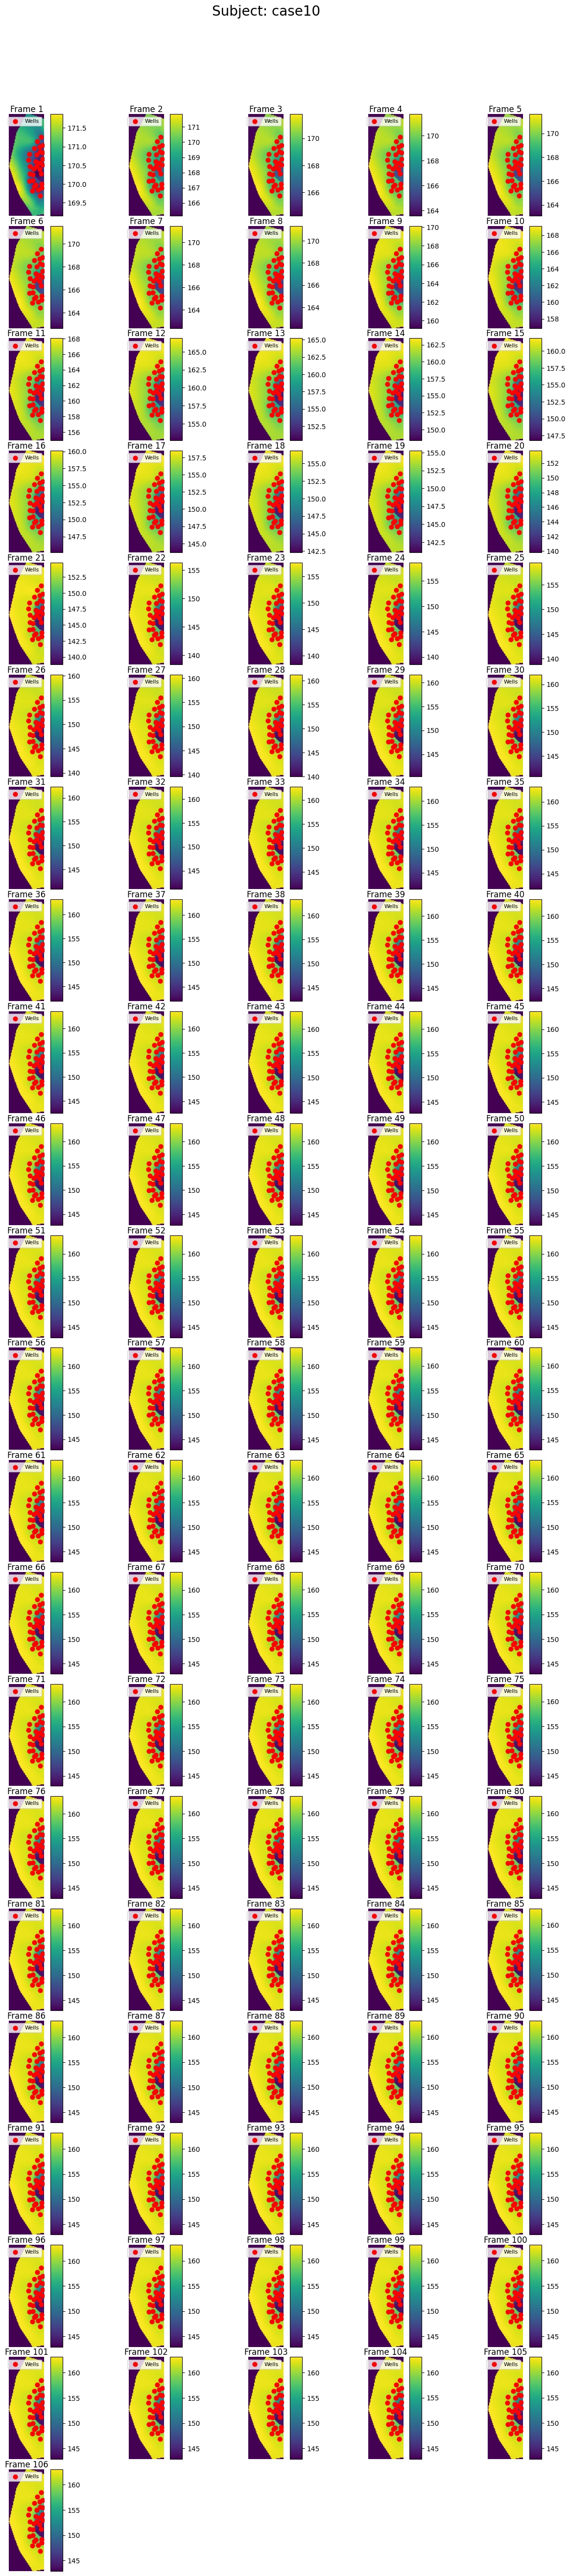

In [29]:
tensor = train_data_list[0][subject_name]
wells_swapped = {k: [[y, x] for x, y in v] for k, v in wells_list[0].items()}

# С минимальными промежутками
visualize_tensor(tensor, subject_name, cmap="viridis", show_colorbar=True, 
                save_path=None, wells=wells_swapped, spacing=0.1)

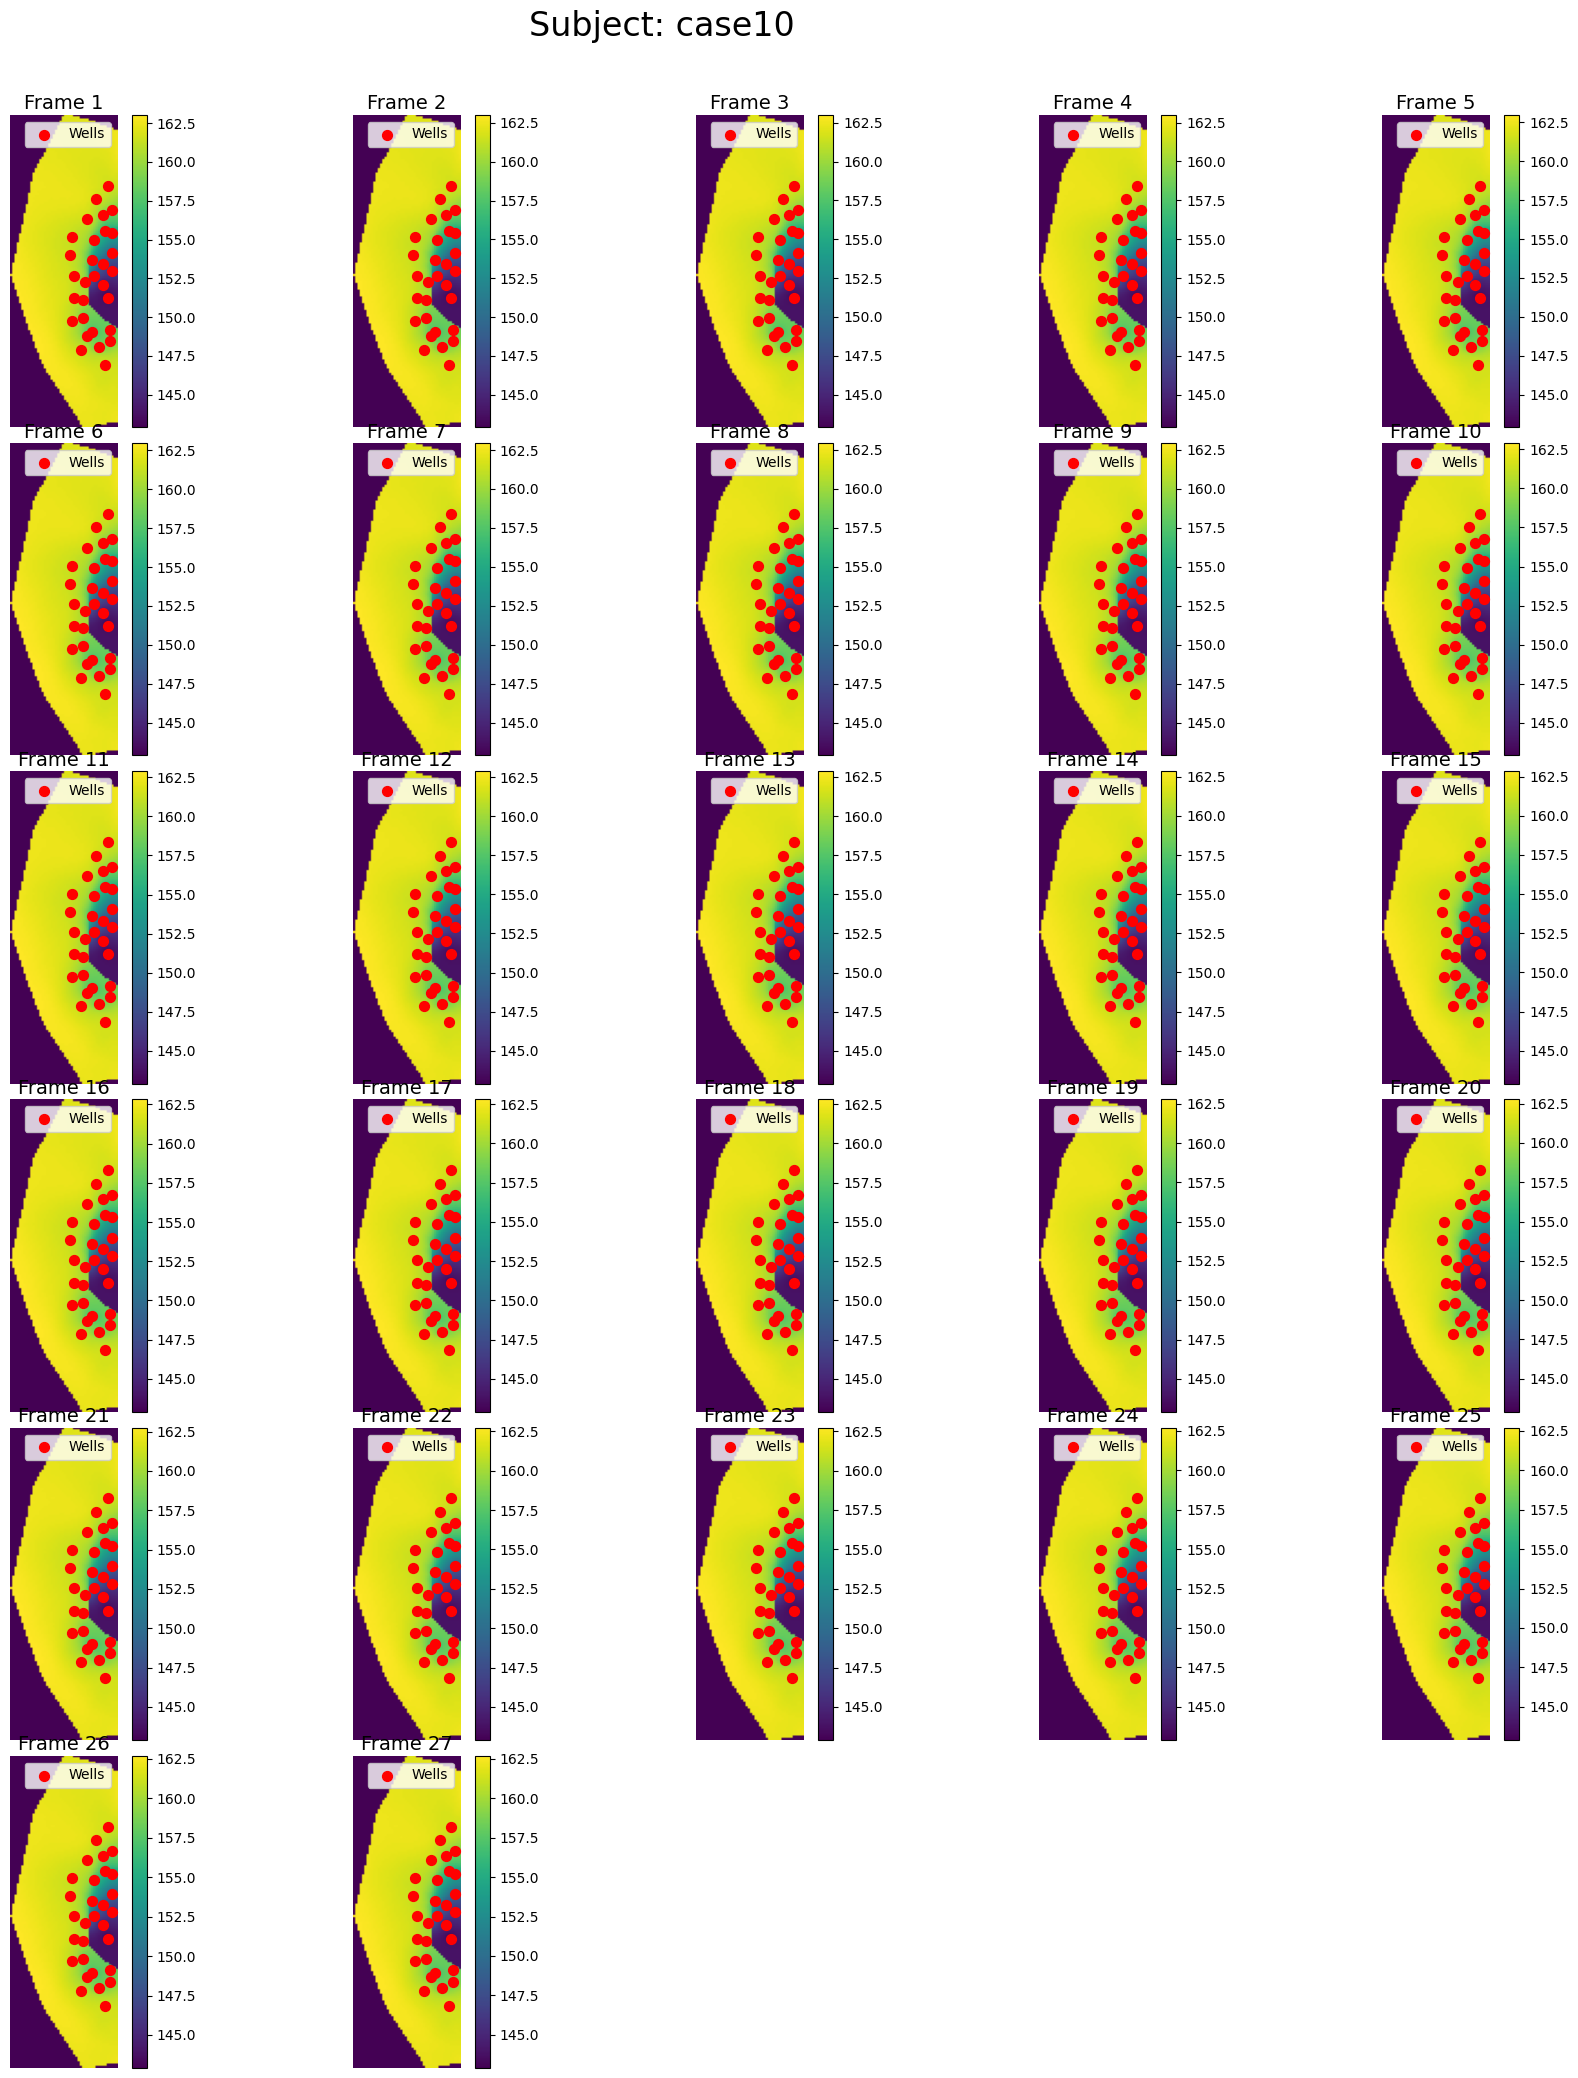

In [25]:
tensor = test_data_list[0][subject_name]
visualize_tensor(tensor, subject_name, cmap="viridis", show_colorbar=True, save_path=None, wells=wells_swapped)  